# BYOCS - Build your own cubic spline ;)

In [1]:
import numpy as np
def thomas_algorithm(a, b, c, d): #from slides/slack 
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def getM(x, y, h, n): #from inclass challenge / slides formula
    
    a = np.zeros(n-2)
    b = np.zeros(n-2)
    c = np.zeros(n-2)
    d = np.zeros(n-2)
    
    #finding tri diag system
    for i in range(1, n - 1):
        a[i - 1] = h[i-1]
        b[i - 1] = 2* (h[i-1]+h[i])
        c[i - 1] = h[i] 
        d[i - 1] = 6*(((y[i+1]-y[i]) / h[i])-((y[i]-y[i-1]) / h[i-1]))
    m = thomas_algorithm(a,b,c,d) #solves the unkowns
    m = np.concatenate(([0], m, [0]))
   # print("m: ", m) #debug
    return m

    
def cubicSpline(x,y, unknownX):
    
    h = x[1:]-x[:-1] #getting the diff intervals
   # print("h:",h) #debug
    n = len(x)
  #  print("n:",n) #debug
    
    m = getM(x,y,h,n) #each sections function
    
    #find interval
    if(unknownX<x[0] or unknownX>x[-1]):
        print("Point out side of scope")
    else:
        
        i = np.searchsorted(x, unknownX) - 1 #had to google how to use this function
        i = np.clip(i,0,n-2) #had to google how to use this function
        #print("section:",i)#debug

        #plugging in!
        term1 = (m[i]/(6*h[i])) * (x[i+1] - unknownX)**3 
        term2 = m[i+1]/(6*h[i]) * (unknownX - x[i])**3
        term3 = (y[i]/h[i] - m[i]*h[i]/6) * (x[i+1]-unknownX)
        term4 = (y[i+1]/h[i] - m[i+1]*h[i]/6) * (unknownX - x[i])
        s = term1+term2+term3+term4
        return s
    
    
    
    

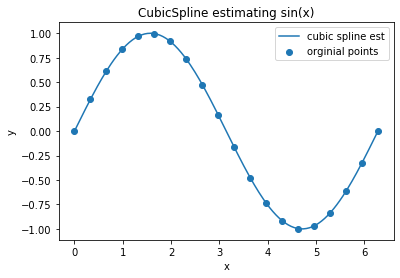

In [4]:
import matplotlib.pyplot as plt
#k known parts
x_known = np.linspace(0,2*np.pi, 20)
y_known = np.sin(x_known)

x_unknowns = np.linspace(0, 2*np.pi, 200)
y_est = np.zeros(len(x_unknowns))

for i in range(0,len(x_unknowns)):
    y_est[i] = cubicSpline(x_known, y_known, x_unknowns[i])
               
plt.scatter(x_known,y_known,label="orginial points")
plt.plot(x_unknowns,y_est, label ="cubic spline est")
plt.title("CubicSpline estimating sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
